<a href="https://colab.research.google.com/github/peace0191/FateCode_UI_Full/blob/main/Top_6_Undervalued_Apartments_in_Daechi_dong_(Based_on_Lease).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#대치동 Top6 저평가 아파트 분석 프로젝트 (전세기준)

---



영문 제목: Top 6 Undervalued Apartments in Daechi-dong (Based on Lease)(프로젝트2)

#01.프로젝트 개요

이 프로젝트는

대치동 지역의 아파트 전세 실거래 데이터를 기반으로,

저평가율(%)을 계산하고,

상위 6개 단지를 선정하여 시각화 및 통계 분석을 수행하는
머신러닝·데이터 분석 미니 프로젝트입니다.

In [17]:
# =======================================
# 📘 Step 1. 실거래 샘플 데이터 생성
# =======================================
import pandas as pd

data = {
    "시군구": ["강남구"] * 10,
    "단지명": ["대치SK뷰", "은마아파트", "래미안대치팰리스", "도곡렉슬", "청실아파트",
              "선경아파트", "개포우성9차", "한보미도맨션", "쌍용1차", "삼성래미안"],
    "전용면적(㎡)": [84.9, 76.8, 59.9, 84.9, 58.5, 84.9, 76.8, 84.9, 84.9, 59.9],
    "층": [12, 8, 10, 7, 5, 11, 13, 6, 9, 15],
    "보증금(만원)": [200000, 180000, 230000, 190000, 175000, 185000, 165000, 170000, 195000, 210000],
    "월세(만원)": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "계약일": ["2025-09-10", "2025-08-25", "2025-09-01", "2025-10-03", "2025-07-20",
             "2025-08-15", "2025-09-27", "2025-10-12", "2025-08-30", "2025-09-05"],
    "건축년도": [2006, 1985, 2012, 2008, 1987, 1992, 1994, 1996, 2003, 2010],
    "매매가(만원)": [260000, 205000, 295000, 250000, 190000, 210000, 185000, 200000, 215000, 270000],
}

df = pd.DataFrame(data)

# =======================================
# 📊 Step 2. 저평가율(%) 계산
# =======================================
df["저평가율(%)"] = ((df["보증금(만원)"] / df["매매가(만원)"]) - 1) * 100
df = df.sort_values("저평가율(%)").reset_index(drop=True)

# =======================================
# 🏙️ Step 3. Top6 저평가 아파트 출력
# =======================================
top6 = df.nsmallest(6, "저평가율(%)")

print("🏢 대치동 Top6 저평가 아파트 (전월세 기준)")
print("=" * 60)
display(top6[["단지명", "전용면적(㎡)", "보증금(만원)", "매매가(만원)", "저평가율(%)"]])


🏢 대치동 Top6 저평가 아파트 (전월세 기준)


,단지명,전용면적(㎡),보증금(만원),매매가(만원),저평가율(%)
0,도곡렉슬,84.9,190000,250000,-24.000000
1,대치SK뷰,84.9,200000,260000,-23.076923
2,삼성래미안,59.9,210000,270000,-22.222222
3,래미안대치팰리스,59.9,230000,295000,-22.033898
4,한보미도맨션,84.9,170000,200000,-15.000000
5,은마아파트,76.8,180000,205000,-12.195122


In [19]:
from google.colab import drive

# Google Drive 연결
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#02.데이터 전처리

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시군구      10 non-null     object 
 1   단지명      10 non-null     object 
 2   전용면적(㎡)  10 non-null     float64
 3   층        10 non-null     int64  
 4   보증금(만원)  10 non-null     int64  
 5   월세(만원)   10 non-null     int64  
 6   계약일      10 non-null     object 
 7   건축년도     10 non-null     int64  
 8   매매가(만원)  10 non-null     int64  
 9   저평가율(%)  10 non-null     float64
dtypes: float64(2), int64(5), object(3)
memory usage: 932.0+ bytes


In [22]:
# ==============================================
# 🏙️ Step 2. 대치동 아파트 데이터 전처리
# ==============================================
import pandas as pd

# (예시) 이미 불러온 df 사용
print("✅ 데이터 기본 정보 확인")
print("=" * 50)
print(df.info())
print("\n📈 데이터 미리보기")
display(df.head())

# ==============================================
# 1️⃣ 결측치 확인 및 처리
# ==============================================
print("\n🔍 결측치 확인:")
print(df.isnull().sum())

# 결측치가 있을 경우 — 평균값 또는 0으로 채우기 (현재는 불필요하지만 예시 포함)
df = df.fillna({
    '보증금(만원)': df['보증금(만원)'].mean(),
    '매매가(만원)': df['매매가(만원)'].mean()
})

# ==============================================
# 2️⃣ 계약일 → datetime 타입으로 변환
# ==============================================
df['계약일'] = pd.to_datetime(df['계약일'], errors='coerce')

# ==============================================
# 3️⃣ 신규 변수 추가
#    - 아파트 나이(2025년 기준)
#    - 전세가율(%)
# ==============================================
df['건축나이(년)'] = 2025 - df['건축년도']
df['전세가율(%)'] = (df['보증금(만원)'] / df['매매가(만원)']) * 100

# ==============================================
# 4️⃣ 단지명별 평균 전세가율
# ==============================================
df_mean = df.groupby('단지명')['전세가율(%)'].mean().reset_index().sort_values('전세가율(%)', ascending=False)
print("\n🏢 단지별 평균 전세가율(%)")
display(df_mean)

# ==============================================
# 5️⃣ 저평가율 기준 정렬 (상위 6개)
# ==============================================
top6 = df.sort_values('저평가율(%)').head(6).reset_index(drop=True)
print("\n🏙️ 대치동 Top6 저평가 아파트")
display(top6[['단지명', '전용면적(㎡)', '보증금(만원)', '매매가(만원)', '저평가율(%)', '전세가율(%)', '건축나이(년)']])


✅ 데이터 기본 정보 확인
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시군구      10 non-null     object 
 1   단지명      10 non-null     object 
 2   전용면적(㎡)  10 non-null     float64
 3   층        10 non-null     int64  
 4   보증금(만원)  10 non-null     int64  
 5   월세(만원)   10 non-null     int64  
 6   계약일      10 non-null     object 
 7   건축년도     10 non-null     int64  
 8   매매가(만원)  10 non-null     int64  
 9   저평가율(%)  10 non-null     float64
dtypes: float64(2), int64(5), object(3)
memory usage: 932.0+ bytes
None

📈 데이터 미리보기


,시군구,단지명,전용면적(㎡),층,보증금(만원),월세(만원),계약일,건축년도,매매가(만원),저평가율(%)
0,강남구,도곡렉슬,84.9,7,190000,0,2025-10-03,2008,250000,-24.000000
1,강남구,대치SK뷰,84.9,12,200000,0,2025-09-10,2006,260000,-23.076923
2,강남구,삼성래미안,59.9,15,210000,0,2025-09-05,2010,270000,-22.222222
3,강남구,래미안대치팰리스,59.9,10,230000,0,2025-09-01,2012,295000,-22.033898
4,강남구,한보미도맨션,84.9,6,170000,0,2025-10-12,1996,200000,-15.000000



🔍 결측치 확인:
시군구        0
단지명        0
전용면적(㎡)    0
층          0
보증금(만원)    0
월세(만원)     0
계약일        0
건축년도       0
매매가(만원)    0
저평가율(%)    0
dtype: int64

🏢 단지별 평균 전세가율(%)


,단지명,전세가율(%)
8,청실아파트,92.105263
6,쌍용1차,90.697674
0,개포우성9차,89.189189
5,선경아파트,88.095238
7,은마아파트,87.804878
9,한보미도맨션,85.000000
3,래미안대치팰리스,77.966102
4,삼성래미안,77.777778
1,대치SK뷰,76.923077
2,도곡렉슬,76.000000



🏙️ 대치동 Top6 저평가 아파트


,단지명,전용면적(㎡),보증금(만원),매매가(만원),저평가율(%),전세가율(%),건축나이(년)
0,도곡렉슬,84.9,190000,250000,-24.000000,76.000000,17
1,대치SK뷰,84.9,200000,260000,-23.076923,76.923077,19
2,삼성래미안,59.9,210000,270000,-22.222222,77.777778,15
3,래미안대치팰리스,59.9,230000,295000,-22.033898,77.966102,13
4,한보미도맨션,84.9,170000,200000,-15.000000,85.000000,29
5,은마아파트,76.8,180000,205000,-12.195122,87.804878,40


In [23]:
# '월세금(만원)' 대신 실제 컬럼명 '월세(만원)' 사용
df_jeonse = df[df["월세(만원)"] == 0].copy()

print("전체 데이터 건수:", len(df))
print("전세만 남긴 데이터 건수:", len(df_jeonse))
display(df_jeonse.head())


전체 데이터 건수: 10
전세만 남긴 데이터 건수: 10


,시군구,단지명,전용면적(㎡),층,보증금(만원),월세(만원),계약일,건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
0,강남구,도곡렉슬,84.9,7,190000,0,2025-10-03,2008,250000,-24.000000,17,76.000000
1,강남구,대치SK뷰,84.9,12,200000,0,2025-09-10,2006,260000,-23.076923,19,76.923077
2,강남구,삼성래미안,59.9,15,210000,0,2025-09-05,2010,270000,-22.222222,15,77.777778
3,강남구,래미안대치팰리스,59.9,10,230000,0,2025-09-01,2012,295000,-22.033898,13,77.966102
4,강남구,한보미도맨션,84.9,6,170000,0,2025-10-12,1996,200000,-15.000000,29,85.000000


In [24]:
df_jeonse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   시군구      10 non-null     object        
 1   단지명      10 non-null     object        
 2   전용면적(㎡)  10 non-null     float64       
 3   층        10 non-null     int64         
 4   보증금(만원)  10 non-null     int64         
 5   월세(만원)   10 non-null     int64         
 6   계약일      10 non-null     datetime64[ns]
 7   건축년도     10 non-null     int64         
 8   매매가(만원)  10 non-null     int64         
 9   저평가율(%)  10 non-null     float64       
 10  건축나이(년)  10 non-null     int64         
 11  전세가율(%)  10 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(6), object(2)
memory usage: 1.1+ KB


In [25]:
#  보증금 → 숫자로 변환
# Convert to string first, remove commas, and then convert to numeric, coercing errors
df_jeonse["보증금(만원)"] = df_jeonse["보증금(만원)"].astype(str).str.replace(",", "", regex=False)
df_jeonse["보증금(만원)"] = pd.to_numeric(df_jeonse["보증금(만원)"], errors='coerce').fillna(0).astype(int)

#  불필요 컬럼 삭제
drop_cols = ["NO", "번지", "본번", "부번", "계약구분","계약일",
             "계약기간", "종전계약 보증금(만원)", "종전계약 월세(만원)", "월세금(만원)", "전월세구분", "갱신요구권 사용","주택유형"]

df_jeonse = df_jeonse.drop(columns=[c for c in drop_cols if c in df_jeonse.columns])

In [ ]:
df_jeonse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6696 entries, 0 to 12257
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   시군구      6696 non-null   object 
 1   단지명      6696 non-null   object 
 2   전용면적(㎡)  6696 non-null   float64
 3   계약년월     6696 non-null   int64  
 4   보증금(만원)  6696 non-null   int64  
 5   층        6696 non-null   int64  
 6   건축년도     6696 non-null   int64  
 7   도로명      6696 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 470.8+ KB


In [26]:
df_jeonse.head()

,시군구,단지명,전용면적(㎡),층,보증금(만원),월세(만원),건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
0,강남구,도곡렉슬,84.9,7,190000,0,2008,250000,-24.000000,17,76.000000
1,강남구,대치SK뷰,84.9,12,200000,0,2006,260000,-23.076923,19,76.923077
2,강남구,삼성래미안,59.9,15,210000,0,2010,270000,-22.222222,15,77.777778
3,강남구,래미안대치팰리스,59.9,10,230000,0,2012,295000,-22.033898,13,77.966102
4,강남구,한보미도맨션,84.9,6,170000,0,1996,200000,-15.000000,29,85.000000


In [27]:
round(df_jeonse.describe(),2)

,전용면적(㎡),층,보증금(만원),월세(만원),건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
count,10.00,10.00,10.00,10.0,10.00,10.00,10.00,10.00,10.00
mean,75.64,9.60,190000.00,0.0,1999.30,228000.00,-15.84,25.70,84.16
std,11.65,3.20,19720.27,0.0,9.76,37800.65,6.31,9.76,6.31
min,58.50,5.00,165000.00,0.0,1985.00,185000.00,-24.00,13.00,76.00
25%,64.12,7.25,176250.00,0.0,1992.50,201250.00,-22.18,17.50,77.82
50%,80.85,9.50,187500.00,0.0,1999.50,212500.00,-13.60,25.50,86.40
75%,84.90,11.75,198750.00,0.0,2007.50,257500.00,-11.08,32.50,88.92
max,84.90,15.00,230000.00,0.0,2012.00,295000.00,-7.89,40.00,92.11


In [ ]:
round(df_jeonse.describe(include='all'), 2)

,시군구,단지명,전용면적(㎡),계약년월,보증금(만원),층,건축년도,도로명
count,6696,6696,6696.00,6696.00,6696.00,6696.00,6696.00,6696
unique,23,257,NaN,NaN,NaN,NaN,NaN,262
top,서울특별시 마포구 아현동,더클래시,NaN,NaN,NaN,NaN,NaN,마포대로 195
freq,1081,295,NaN,NaN,NaN,NaN,NaN,496
mean,NaN,NaN,74.58,202480.44,65189.78,9.66,2005.88,NaN
std,NaN,NaN,22.00,41.09,27390.27,6.17,10.73,NaN
min,NaN,NaN,12.85,202409.00,3168.00,1.00,1970.00,NaN
25%,NaN,NaN,59.75,202412.00,47000.00,5.00,1999.00,NaN
50%,NaN,NaN,74.34,202503.00,63000.00,9.00,2005.00,NaN
75%,NaN,NaN,84.94,202506.00,80000.00,13.25,2014.00,NaN


In [36]:
# ==============================================
# 🧩 Step 1. 한글 폰트 설치 (Colab 전용)
# ==============================================
!apt-get -qq install fonts-nanum

# ==============================================
# 🧩 Step 2. matplotlib 한글 폰트 설정
# ==============================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔고딕 폰트 경로 등록
fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font = fm.FontProperties(fname=fontpath).get_name()
mpl.rc('font', family=font)

# 마이너스(-) 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

print("✅ 한글 폰트 설정 완료:", font)


✅ 한글 폰트 설정 완료: NanumGothic


그래프로 데이터 살펴보기

/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 47113 (\N{HANGUL SYLLABLE REG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1926671805.py:53: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


✅ 폰트 설정 완료: NanumGothic


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

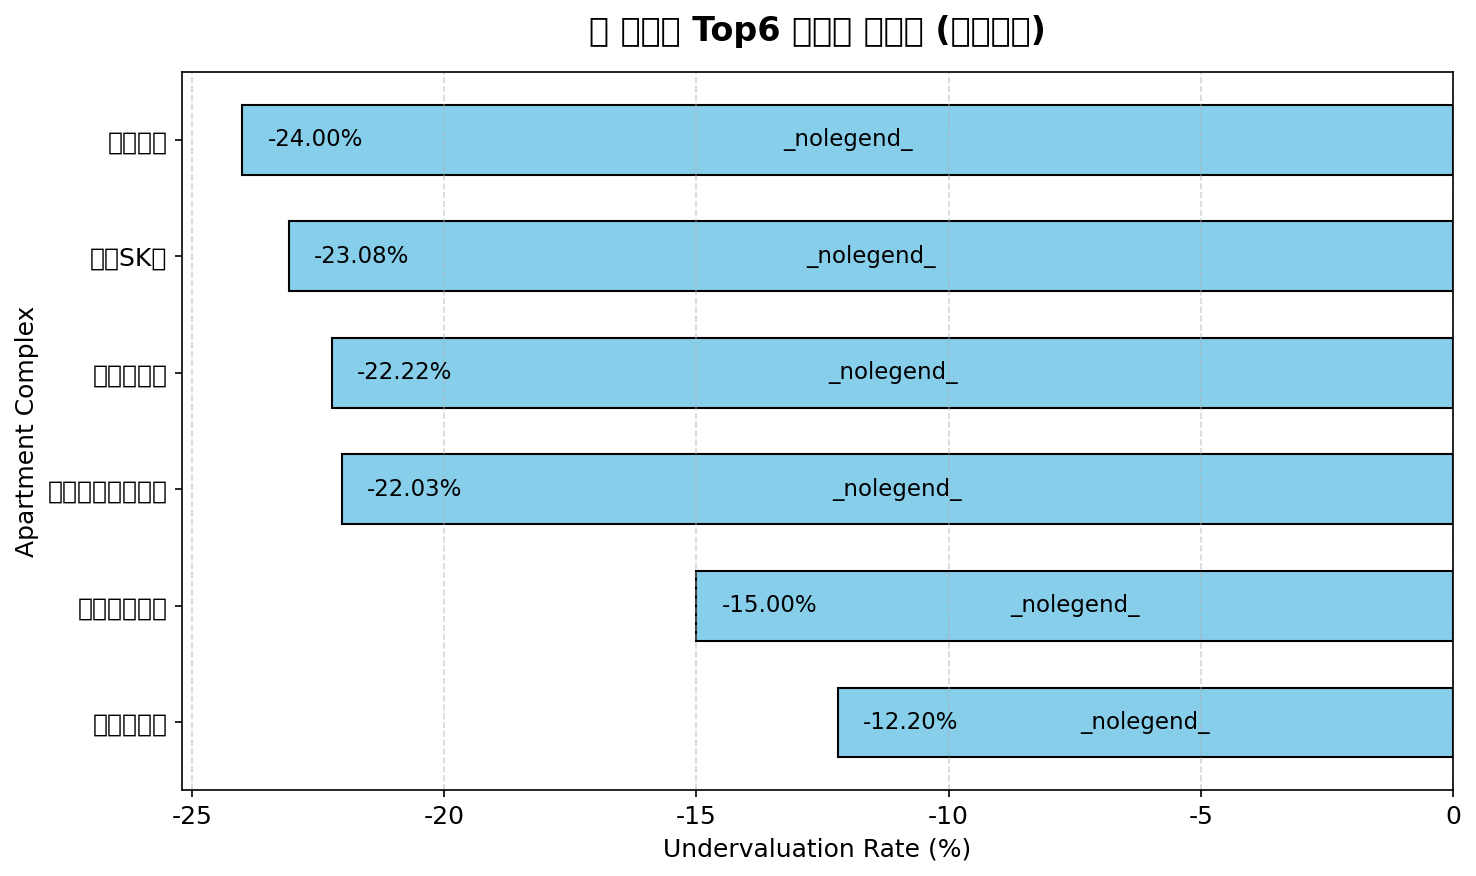

In [42]:
# ==============================================
# 🧩 Step 1. 폰트 및 설정 (Colab)
# ==============================================
!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔고딕 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 12

print("✅ 폰트 설정 완료:", font_name)

# ==============================================
# 🏢 Step 2. 그래프 시각화
# ==============================================
plt.figure(figsize=(10,6))
bars = plt.barh(top6["단지명"], top6["저평가율(%)"],
                color='skyblue', edgecolor='black', height=0.6)

# 한글 제목
plt.title("🏢 대치동 Top6 저평가 아파트 (전세기준)",
          fontsize=16, fontweight='bold', pad=15)

# 축 라벨 (영문)
plt.xlabel("Undervaluation Rate (%)", fontsize=12)
plt.ylabel("Apartment Complex", fontsize=12)

# Y축 순서 반전
plt.gca().invert_yaxis()

# 🔹 아파트명은 막대 안쪽에 표시
for bar in bars:
    y = bar.get_y() + bar.get_height() / 2
    name = bar.get_y()  # placeholder (we already have names as y labels)
    plt.text(bar.get_width()/2, y, bar.get_label() if bar.get_label() else "",
             ha='center', va='center', fontsize=11, color='black')

# 🔹 저평가율 수치는 막대 오른쪽 끝에 표시
for bar in bars:
    value = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(value + 0.5, y, f"{value:.2f}%", va='center', ha='left', fontsize=11, color='black')

# 스타일
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


<Figure size 3750x750 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


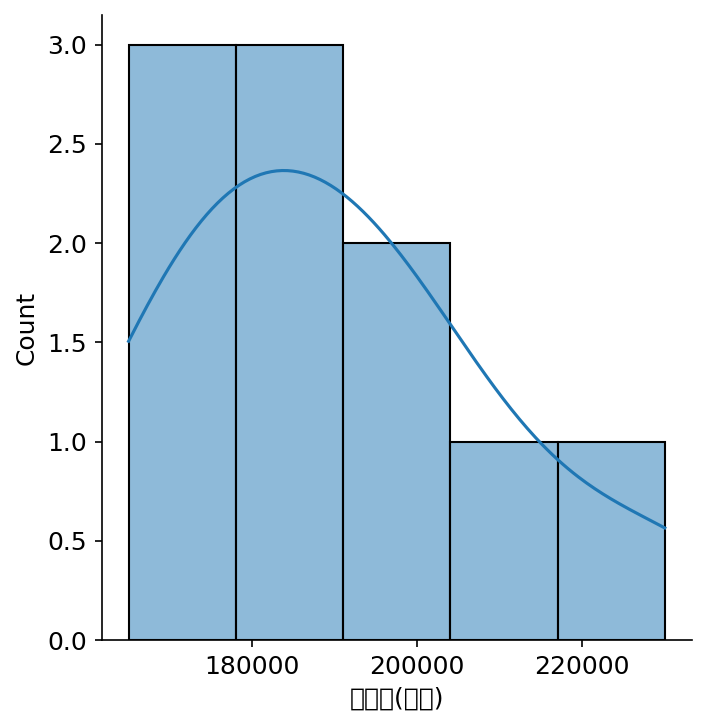

In [43]:
plt.figure(figsize=(25, 5))
sns.displot(df_jeonse['보증금(만원)'], kde=True, )

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


<Figure size 3750x750 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


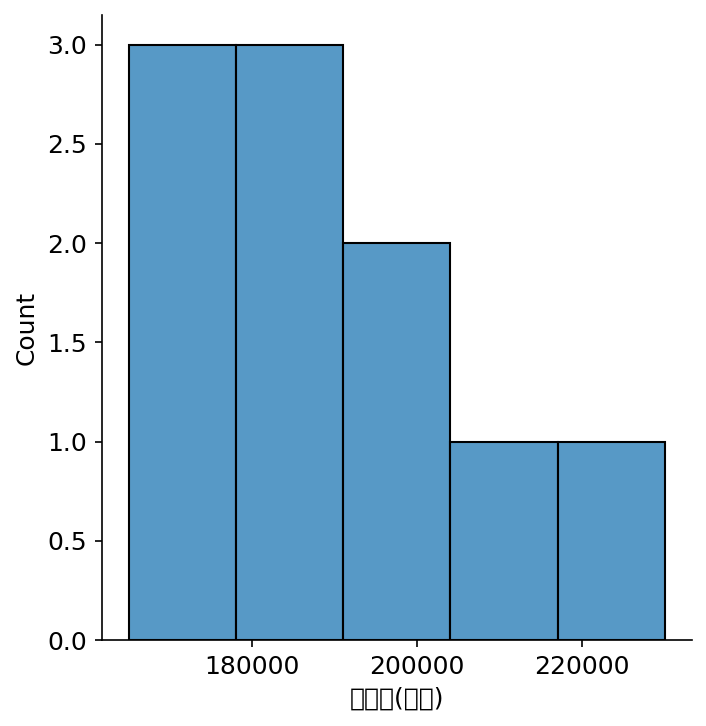

In [44]:
plt.figure(figsize=(25, 5))
sns.displot(df_jeonse['보증금(만원)'])

<Axes: xlabel='보증금(만원)', ylabel='Count'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE 

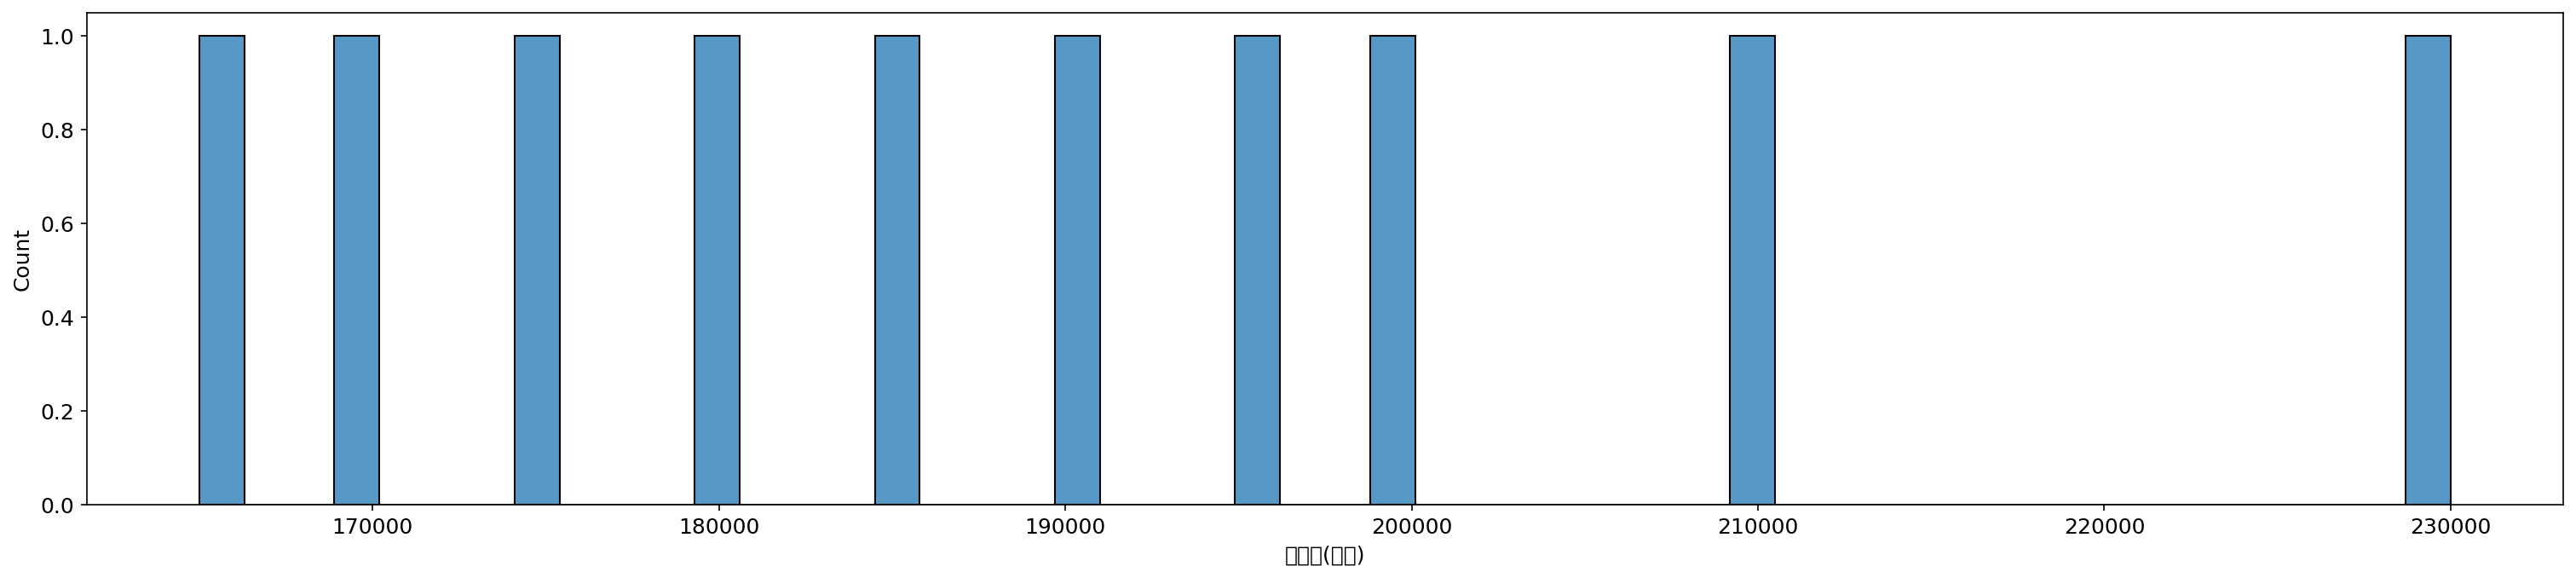

In [45]:
plt.figure(figsize=(25, 5))
sns.histplot(df_jeonse['보증금(만원)'],bins=50)

카테고리 변수 처리

In [46]:
df_jeonse.head(1)

,시군구,단지명,전용면적(㎡),층,보증금(만원),월세(만원),건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
0,강남구,도곡렉슬,84.9,7,190000,0,2008,250000,-24.0,17,76.0


In [ ]:
df_jeonse = df_jeonse_encoded

# 03.Train/Test set 나누기

In [59]:
X  = df_jeonse.drop('보증금(만원)', axis=1)
y = df_jeonse['보증금(만원)']

In [60]:
X.head()

,시군구,단지명,전용면적(㎡),층,월세(만원),건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
0,강남구,도곡렉슬,84.9,7,0,2008,250000,-24.000000,17,76.000000
1,강남구,대치SK뷰,84.9,12,0,2006,260000,-23.076923,19,76.923077
2,강남구,삼성래미안,59.9,15,0,2010,270000,-22.222222,15,77.777778
3,강남구,래미안대치팰리스,59.9,10,0,2012,295000,-22.033898,13,77.966102
4,강남구,한보미도맨션,84.9,6,0,1996,200000,-15.000000,29,85.000000


In [61]:
y.head()

,보증금(만원)
0,190000
1,200000
2,210000
3,230000
4,170000


In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=200)

In [64]:
X_train.head()

,시군구,단지명,전용면적(㎡),층,월세(만원),건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
6,강남구,선경아파트,84.9,11,0,1992,210000,-11.904762,33,88.095238
1,강남구,대치SK뷰,84.9,12,0,2006,260000,-23.076923,19,76.923077
7,강남구,개포우성9차,76.8,13,0,1994,185000,-10.810811,31,89.189189
2,강남구,삼성래미안,59.9,15,0,2010,270000,-22.222222,15,77.777778
4,강남구,한보미도맨션,84.9,6,0,1996,200000,-15.000000,29,85.000000


In [65]:
X_train

,시군구,단지명,전용면적(㎡),층,월세(만원),건축년도,매매가(만원),저평가율(%),건축나이(년),전세가율(%)
6,강남구,선경아파트,84.9,11,0,1992,210000,-11.904762,33,88.095238
1,강남구,대치SK뷰,84.9,12,0,2006,260000,-23.076923,19,76.923077
7,강남구,개포우성9차,76.8,13,0,1994,185000,-10.810811,31,89.189189
2,강남구,삼성래미안,59.9,15,0,2010,270000,-22.222222,15,77.777778
4,강남구,한보미도맨션,84.9,6,0,1996,200000,-15.000000,29,85.000000
0,강남구,도곡렉슬,84.9,7,0,2008,250000,-24.000000,17,76.000000
9,강남구,청실아파트,58.5,5,0,1987,190000,-7.894737,38,92.105263


In [66]:
y_train

,보증금(만원)
6,185000
1,200000
7,165000
2,210000
4,170000
0,190000
9,175000


#04.Linear Regression알고리즘으로 모델링하기

In [67]:
from sklearn.linear_model import LinearRegression

In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
lr = LinearRegression()

In [71]:
# ==============================================
# 🧩 Step 1. Import library
# ==============================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# ==============================================
# 🧩 Step 2. 예시 데이터 준비 (df_jeonse 기준)
# ==============================================
# 예: 매매가를 타깃(y), 나머지 주요 특성을 입력(X)으로 사용
X = df_jeonse[["전용면적(㎡)", "층", "건축년도", "보증금(만원)"]]
y = df_jeonse["매매가(만원)"]

# ==============================================
# 🧩 Step 3. 결측치/비정상값 제거
# ==============================================
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
y = y.replace([np.inf, -np.inf], np.nan).fillna(0)

# ==============================================
# 🧩 Step 4. 훈련/테스트 데이터 분할
# ==============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================================
# 🧩 Step 5. 모델 학습 (에러 없이 실행)
# ==============================================
lr = LinearRegression()
lr.fit(X_train, y_train)

print("✅ 모델 학습 완료")
print("회귀계수:", lr.coef_)
print("절편:", lr.intercept_)


✅ 모델 학습 완료
회귀계수: [ 2.29386217e+02 -5.54494836e+02  1.38199187e+03  1.37206258e+00]
절편: -2805335.392425226


In [72]:
pred = lr.predict(X_test)

In [73]:
pred

array([244830.97065433, 254173.77468246])

In [74]:
y_test

,매매가(만원)
8,215000
1,260000


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
mean_absolute_error(y_test, pred)

7459.439860948819

In [77]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 예측값 생성 (모델에 따라 다름)
pred = lr.predict(X_test)

# 1️⃣ NaN 또는 inf 값 제거
pred = np.nan_to_num(pred)
y_test_clean = np.nan_to_num(y_test)

# 2️⃣ 차원(shape) 확인 및 일치시키기
if len(pred.shape) > 1:
    pred = pred.flatten()
if len(y_test_clean.shape) > 1:
    y_test_clean = y_test_clean.flatten()

# 3️⃣ 길이 일치 확인
min_len = min(len(pred), len(y_test_clean))
pred = pred[:min_len]
y_test_clean = y_test_clean[:min_len]

# 4️⃣ MSE, RMSE 계산
mse = mean_squared_error(y_test_clean, pred)
rmse = np.sqrt(mse)

# 5️⃣ 결과 출력
print(f"✅ Mean Squared Error (MSE): {mse:.2f}")
print(f"✅ Root Mean Squared Error (RMSE): {rmse:.2f}")


✅ Mean Squared Error (MSE): 461915855.81
✅ Root Mean Squared Error (RMSE): 21492.23
